Import delle librerie

In [5]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# NLP e Preprocessing
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download delle risorse NLTK necessarie (avviene solo la prima volta)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Machine Learning
from sklearn.metrics import precision_score, recall_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rubengigante/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/rubengigante/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/rubengigante/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Caricamento dei dati e Label Encoding




In [6]:
# Caricamento dei file CSV
df_train = pd.read_csv("../data/train_set.csv")
df_test = pd.read_csv("../data/test_set.csv")

print(f"Dimensioni Train Set: {df_train.shape}")
print(f"Dimensioni Test Set: {df_test.shape}")

# Mappatura delle label: bug -> 0, feature -> 1
label_mapping = {'bug': 0, 'feature': 1}
df_train['label_num'] = df_train['label'].map(label_mapping)
df_test['label_num'] = df_test['label'].map(label_mapping)

# Visualizzazione delle prime righe del Train per controllo
df_train.head()

Dimensioni Train Set: (32650, 2)
Dimensioni Test Set: (13994, 2)


,text,label,label_num
0,"The `extern ""C""` ABI of SIMD vector types depe...",feature,1
1,Multiplayer synchronized doesn't emit synchron...,bug,0
2,`Overflow` in `tf.raw_ops.SerializeManySparse`...,bug,0
3,Command Center customization <!-- ⚠️⚠️ Do Not ...,feature,1
4,Generic function with function as argument aut...,feature,1


Definizione della funzione di Preprocessing

Inizializziamo lo stemmer e le stop words inglesi, poi creiamo la funzione per pulire il testo.

In [7]:
# Inizializzazione degli strumenti NLP
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))
punctuation_set = set(string.punctuation)

def clean_text(text):
    # 1. Minuscolo
    text = str(text).lower()
    
    # 2. Rimozione punteggiatura e tokenizzazione semplice
    tokens = nltk.word_tokenize(text)
    
    cleaned_tokens = []
    for token in tokens:
        # Rimuove i token che sono solo punteggiatura
        token_clean = "".join([char for char in token if char not in punctuation_set])
        
        # 3. Rimozione stop words e applicazione dello Stemming
        if token_clean and token_clean not in stop_words:
            stemmed_token = stemmer.stem(token_clean)
            cleaned_tokens.append(stemmed_token)
            
    # Ricostruisce la stringa pulita
    return " ".join(cleaned_tokens)


Applicazione del Preprocessing

Applichiamo la funzione appena creata alla colonna text sia del Train che del Test.

In [8]:
print("Applicazione del preprocessing sul Train Set...")
df_train['clean_text'] = df_train['text'].apply(clean_text)

print("Applicazione del preprocessing sul Test Set...")
df_test['clean_text'] = df_test['text'].apply(clean_text)

print("Preprocessing completato!")

Applicazione del preprocessing sul Train Set...
Applicazione del preprocessing sul Test Set...
Preprocessing completato!


Vettorizzazione TF-IDF

Inizializziamo il vettorizzatore. Facciamo il fit_transform solo sul Train e il transform sul Test per evitare data leakage.

In [9]:
# Inizializzazione del TF-IDF Vectorizer
tfidf = TfidfVectorizer(max_features=5000) # Limitiamo a 5000 feature per evitare matrici troppo sparse, puoi variare questo parametro

# Estrazione delle feature
X_train = tfidf.fit_transform(df_train['clean_text'])
X_test = tfidf.transform(df_test['clean_text'])

# Target arrays
y_train = df_train['label_num'].values
y_test = df_test['label_num'].values

print(f"Formato matrice TF-IDF Train: {X_train.shape}")
print(f"Formato matrice TF-IDF Test:  {X_test.shape}")

Formato matrice TF-IDF Train: (32650, 5000)
Formato matrice TF-IDF Test:  (13994, 5000)


Training e Validazione Modello A (Logistic Regression)

Valutiamo il modello con una Cross-Validation a 5 fold sul Train, poi facciamo il fit finale e prediciamo sul Test.

In [10]:
print("--- MODELLO A: LOGISTIC REGRESSION ---")

# Inizializzazione modello
lr_model = LogisticRegression(random_state=42, max_iter=1000)

# Cross-Validation sul Train Set (usiamo sempre F1 come metrica principale di guida)
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=5, scoring='f1')
print(f"F1-Score medio in Cross-Validation (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Fit finale su tutto il Train Set
lr_model.fit(X_train, y_train)

# Predizione sul Test Set
y_pred_lr = lr_model.predict(X_test)

# Calcolo di tutte le metriche sul Test Set
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(f"\nRisultati sul Test Set:")
print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}  (Capacità di non scambiare un bug per una feature)")
print(f"Recall:    {recall_lr:.4f}  (Capacità di trovare tutte le feature)")
print(f"F1-Score:  {f1_lr:.4f}")
print("\nMatrice di Confusione:")
print(cm_lr)

--- MODELLO A: LOGISTIC REGRESSION ---
F1-Score medio in Cross-Validation (5-fold): 0.8751 (+/- 0.0022)

Risultati sul Test Set:
Accuracy:  0.8843
Precision: 0.8998  (Capacità di non scambiare un bug per una feature)
Recall:    0.8649  (Capacità di trovare tutte le feature)
F1-Score:  0.8820

Matrice di Confusione:
[[6323  674]
 [ 945 6052]]


Training e Validazione Modello B (Decision Tree)

Ripetiamo lo stesso identico processo utilizzando un Decision Tree Classifier.

In [11]:
print("--- MODELLO B: DECISION TREE ---")

# Inizializzazione modello
dt_model = DecisionTreeClassifier(random_state=42, max_depth=15)

# Cross-Validation sul Train Set
cv_scores_dt = cross_val_score(dt_model, X_train, y_train, cv=5, scoring='f1')
print(f"F1-Score medio in Cross-Validation (5-fold): {cv_scores_dt.mean():.4f} (+/- {cv_scores_dt.std():.4f})")

# Fit finale su tutto il Train Set
dt_model.fit(X_train, y_train)

# Predizione sul Test Set
y_pred_dt = dt_model.predict(X_test)

# Calcolo di tutte le metriche sul Test Set
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(f"\nRisultati sul Test Set:")
print(f"Accuracy:  {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall:    {recall_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print("\nMatrice di Confusione:")
print(cm_dt)

--- MODELLO B: DECISION TREE ---
F1-Score medio in Cross-Validation (5-fold): 0.8465 (+/- 0.0025)

Risultati sul Test Set:
Accuracy:  0.8559
Precision: 0.8654
Recall:    0.8428
F1-Score:  0.8540

Matrice di Confusione:
[[6080  917]
 [1100 5897]]


Training e validazione del modello C

SVM

In [ ]:
print("--- MODELLO C: SUPPORT VECTOR MACHINE (SVM) ---")

# Inizializzazione modello
# Usiamo il kernel 'linear' o 'rbf' (default). Il kernel lineare è spesso ottimo per il testo con TF-IDF.
svm_model = SVC(kernel='linear', random_state=42)

# Cross-Validation sul Train Set
cv_scores_svm = cross_val_score(svm_model, X_train, y_train, cv=5, scoring='f1')
print(f"F1-Score medio in Cross-Validation (5-fold): {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})")

# Fit finale su tutto il Train Set
svm_model.fit(X_train, y_train)

# Predizione sul Test Set
y_pred_svm = svm_model.predict(X_test)

# Calcolo di tutte le metriche sul Test Set
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print(f"\nRisultati sul Test Set:")
print(f"Accuracy:  {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall:    {recall_svm:.4f}")
print(f"F1-Score:  {f1_svm:.4f}")
print("\nMatrice di Confusione:")
print(cm_svm)

--- MODELLO C: SUPPORT VECTOR MACHINE (SVM) ---


Confronto delle Metriche


--- CONFRONTO FINALE DELLE METRICHE (TEST SET) ---
   Metric  Logistic Regression (Modello A)  Decision Tree (Modello B)  SVM (Modello C)
 Accuracy                         0.884308                   0.855224         0.881020
Precision                         0.899792                   0.862794         0.898863
   Recall                         0.864942                   0.844791         0.858654
 F1-Score                         0.882023                   0.853697         0.878298


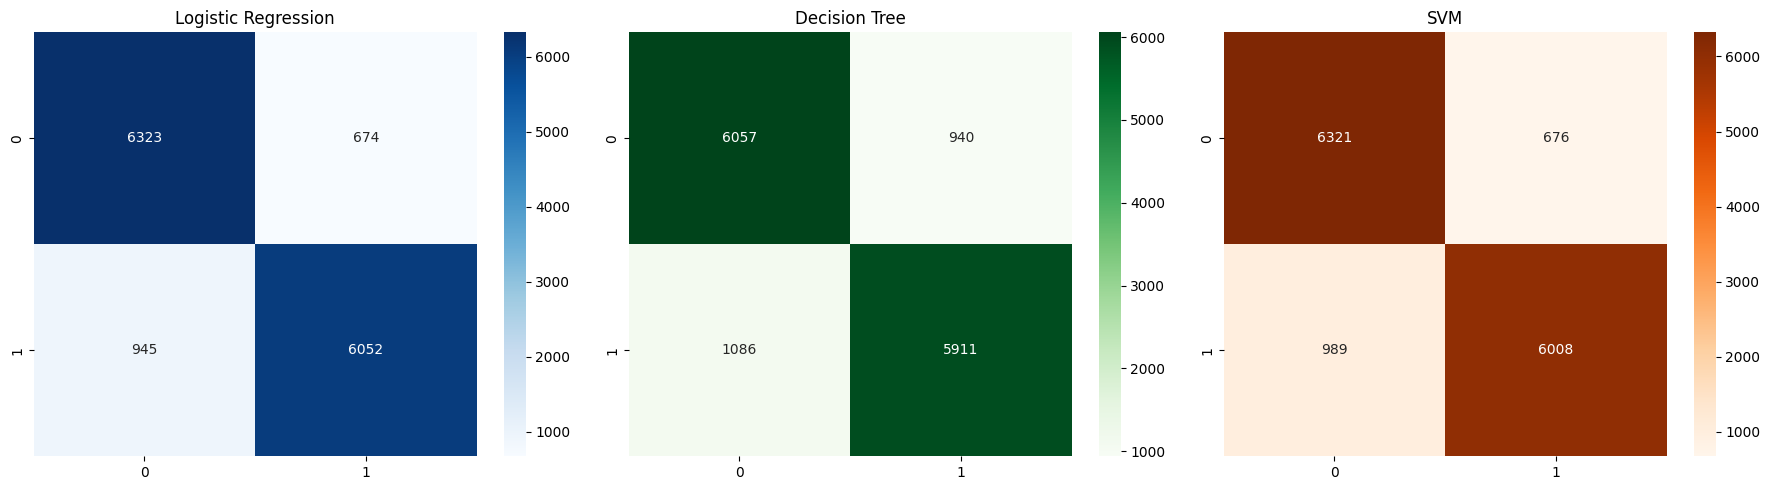

In [10]:
# Creazione di un DataFrame comparativo aggiornato
df_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression (Modello A)': [accuracy_lr, precision_lr, recall_lr, f1_lr],
    'Decision Tree (Modello B)': [accuracy_dt, precision_dt, recall_dt, f1_dt],
    'SVM (Modello C)': [accuracy_svm, precision_svm, recall_svm, f1_svm]
})

print("--- CONFRONTO FINALE DELLE METRICHE (TEST SET) ---")
print(df_comparison.to_string(index=False))

# Crea una riga con tre spazi per i grafici
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Matrice Modello A
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')

# Matrice Modello B
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')

# Matrice Modello C
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('SVM')

plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png')
plt.show()

Salvataggio dei Risultati

In [12]:
import json

tfidf_results_json = {
    'logistic_regression': {
        'accuracy': float(accuracy_lr),
        'precision': float(precision_lr),
        'recall': float(recall_lr),
        'f1_score': float(f1_lr),
        'confusion_matrix': cm_lr.tolist()
    },
    'decision_tree': {
        'accuracy': float(accuracy_dt),
        'precision': float(precision_dt),
        'recall': float(recall_dt),
        'f1_score': float(f1_dt),
        'confusion_matrix': cm_dt.tolist()
    },
    'svm': {
        'accuracy': float(accuracy_svm),
        'precision': float(precision_svm),
        'recall': float(recall_svm),
        'f1_score': float(f1_svm),
        'confusion_matrix': cm_svm.tolist()
    }
}

# Path nella cartella results/
output_json_path = "../results/tfidf_results.json"

with open(output_json_path, 'w', encoding='utf-8') as f:
    json.dump(tfidf_results_json, f, indent=4)

print(f"Risultati salvati in: {output_json_path}")

Risultati salvati in: ../results/tfidf_results.json
